In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_exhaustion(alpha_start, decay_rate, sigma, T=20, dt=0.01):
    steps = int(T / dt)
    x, y, z = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    x[0], y[0] = 1.0, 0.0

    # Store alpha over time to see the 'battery' dying
    alpha_history = []

    for i in range(1, steps):
        # The 'Battery' Logic: Alpha decays exponentially over time
        alpha_t = alpha_start * np.exp(-decay_rate * (i * dt))
        alpha_history.append(alpha_t)

        dx = -y[i-1] * dt
        dy = x[i-1] * dt

        # The Lift (now powered by a dying battery)
        area_element = (x[i-1] * dy - y[i-1] * dx)
        dz = alpha_t * area_element + sigma * np.random.normal(0, np.sqrt(dt))

        x[i] = x[i-1] + dx
        y[i] = y[i-1] + dy
        z[i] = z[i-1] + dz

    return x, y, z, alpha_history

# --- Run the Exhaustion Trial ---
# start with 3.0 alpha, but it decays at a rate of 0.2
x_e, y_e, z_e, a_hist = simulate_exhaustion(alpha_start=3.0, decay_rate=0.2, sigma=0.05)

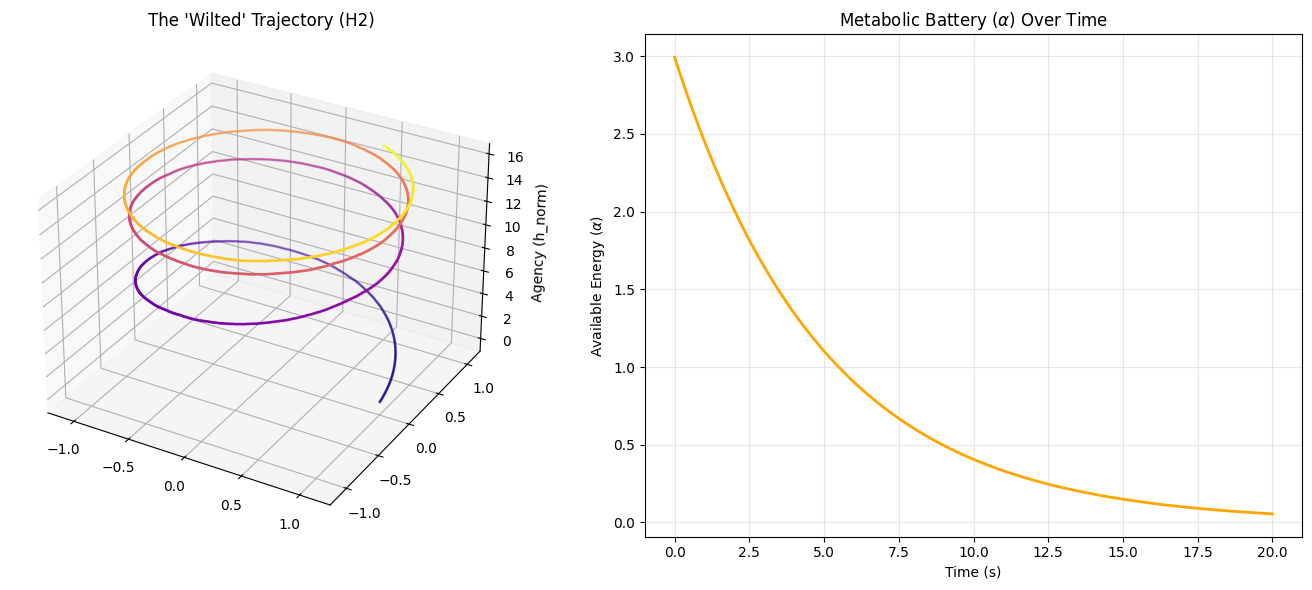

In [9]:
fig = plt.figure(figsize=(14, 6))

# Panel 1: The 3D Trajectory
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(x_e, y_e, z_e, c=np.linspace(0, 1, len(z_e)), cmap='plasma', s=1)
ax1.set_title("The 'Wilted' Trajectory (H2)")
ax1.set_zlabel("Agency (h_norm)")

# Panel 2: The Energy Drain
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(np.linspace(0, 20, len(a_hist)), a_hist, color='orange', lw=2)
ax2.set_title(r"Metabolic Battery ($\alpha$) Over Time")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Available Energy ($\alpha$)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

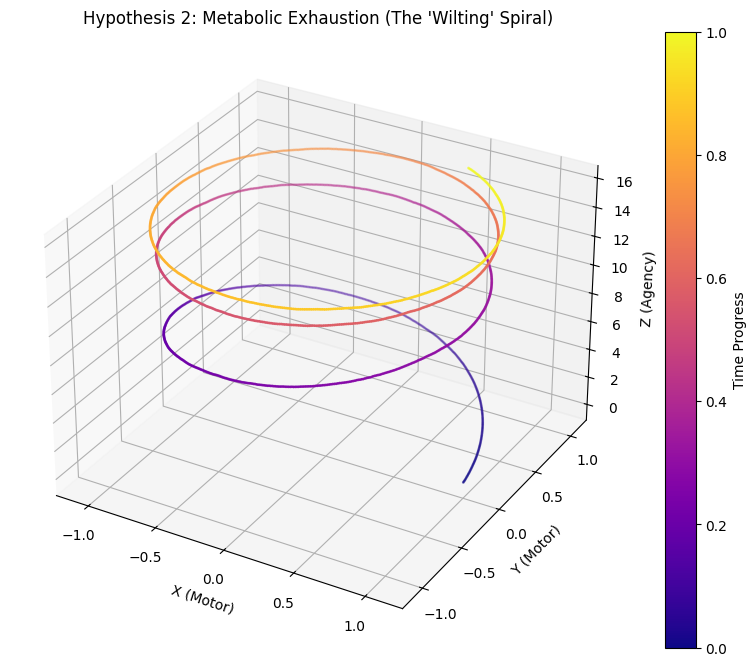

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory
# We use a colormap to show time passing (Purple = Start, Yellow = End)
sc = ax.scatter(x_e, y_e, z_e, c=np.linspace(0, 1, len(z_e)), cmap='plasma', s=1)

ax.set_title("Hypothesis 2: Metabolic Exhaustion (The 'Wilting' Spiral)")
ax.set_xlabel("X (Motor)")
ax.set_ylabel("Y (Motor)")
ax.set_zlabel("Z (Agency)")
plt.colorbar(sc, label="Time Progress")
plt.show()